# TF / IDF Normalization Comparison for Indian Language Identification

This notebook builds on the **previous assignment** (IndicCorp v2 language identification
dataset + from-scratch TF-IDF vectorizer + from-scratch softmax logistic regression). It
reuses the same `train.csv` / `val.csv` / `test.csv` splits and adds:

1. **Two TF normalization schemes**, in addition to the unnormalized (raw count) TF from
   the previous assignment:
   - **(a) Total-words normalization** — divide by the total number of terms in the
     sentence (classic relative-frequency TF).
   - **(b) Max-frequency normalization** — divide by the frequency of the most frequent
     term in that sentence.
2. **One IDF normalization scheme**, in addition to the unnormalized (smoothed-log) IDF
   from the previous assignment:
   - **Max-document-frequency normalization** — scale IDF relative to the document
     frequency of the *most frequent term across the whole corpus*.
3. A **from-scratch multinomial logistic regression** trained and evaluated (macro-F1,
   from scratch) on **all 6 TF × IDF combinations**, so we can compare unnormalized vs.
   normalized TF/IDF head-to-head.

As before, **no `sklearn` classes** are used for feature extraction, modeling, or
evaluation — `scipy.sparse` is used only as an efficient numeric container.


In [1]:
import re
import json
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import Counter

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Step 1: Load the dataset from the previous assignment

We reuse `train.csv`, `val.csv`, `test.csv`, and `label_map.json` produced by the
previous assignment's notebook. If you haven't run that notebook in this environment
yet, run it first (or copy those files next to this notebook) — this notebook does not
re-download or re-split the IndicCorp v2 data.


In [2]:
DATA_FILES = ["train.csv", "val.csv", "test.csv", "label_map.json"]
missing = [f for f in DATA_FILES if not __import__("os").path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"Missing files: {missing}. Please run the previous assignment's notebook "
        f"first (it saves train.csv / val.csv / test.csv / label_map.json into the "
        f"working directory), or copy those files here."
    )

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

with open("label_map.json", encoding="utf-8") as f:
    id2lang = {int(k): v for k, v in json.load(f).items()}
lang2id = {v: k for k, v in id2lang.items()}

n_classes = len(lang2id)
print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print("Number of languages:", n_classes)

y_train = train_df["language"].map(lang2id).to_numpy()
y_val = val_df["language"].map(lang2id).to_numpy()
y_test = test_df["language"].map(lang2id).to_numpy()


Train: (18400, 3)  Val: (2300, 3)  Test: (2300, 3)
Number of languages: 23


## Step 2: Feature extraction (recap)

We reuse the exact same feature space as the previous assignment: word unigrams +
bigrams (Unicode-aware `\w+` tokenizer), and character 2/3/4-grams with `#`-padded word
boundaries. Keeping the feature space identical across all 6 TF×IDF combinations makes
the comparison fair — only the *weighting scheme* changes, not the vocabulary.


In [3]:
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def word_tokens(text):
    return TOKEN_RE.findall(text)

def word_ngrams(tokens, ngram_range=(1, 2)):
    feats = []
    lo, hi = ngram_range
    for n in range(lo, hi + 1):
        if n == 1:
            feats.extend(f"W1_{t}" for t in tokens)
        else:
            for i in range(len(tokens) - n + 1):
                feats.append(f"W{n}_" + "_".join(tokens[i:i + n]))
    return feats

def char_ngrams(text, sizes=(2, 3, 4)):
    feats = []
    for word in text.split():
        padded = f"#{word}#"
        for n in sizes:
            if len(padded) < n:
                continue
            for i in range(len(padded) - n + 1):
                feats.append(f"C{n}_" + padded[i:i + n])
    return feats

def extract_features(raw_text, lowercase=True, word_ngram_range=(1, 2), char_sizes=(2, 3, 4)):
    text = raw_text.lower() if lowercase else raw_text
    tokens = word_tokens(text)
    feats = word_ngrams(tokens, word_ngram_range)
    feats.extend(char_ngrams(text, char_sizes))
    return feats


## Step 3: Build the vocabulary and raw term-count matrices (shared across all combos)

We build the vocabulary **once**, from the training set only (`min_df` + `max_features`
pruning, same as the previous assignment), and compute the raw term-count matrix for
train/val/test **once**. Every one of the 6 TF×IDF combinations below is just a different
re-weighting of these same raw counts — so we don't repeat tokenization/counting 6
times.


In [4]:
def build_vocabulary(corpus, min_df=2, max_features=60000):
    doc_freq = Counter()
    term_freq_total = Counter()
    tokenized_docs = []

    for doc in corpus:
        feats = extract_features(doc)
        tokenized_docs.append(feats)
        for f in set(feats):
            doc_freq[f] += 1
        term_freq_total.update(feats)

    candidate_terms = [t for t, df_ in doc_freq.items() if df_ >= min_df]
    if max_features is not None and len(candidate_terms) > max_features:
        candidate_terms = sorted(
            candidate_terms, key=lambda t: term_freq_total[t], reverse=True
        )[:max_features]
    candidate_terms = sorted(candidate_terms)

    vocabulary = {t: i for i, t in enumerate(candidate_terms)}
    doc_freq_array = np.array([doc_freq[t] for t in candidate_terms], dtype=np.float64)
    return vocabulary, doc_freq_array, tokenized_docs


def docs_to_count_matrix(tokenized_docs, vocabulary):
    n_docs = len(tokenized_docs)
    n_feats = len(vocabulary)
    rows, cols, data = [], [], []
    for r, feats in enumerate(tokenized_docs):
        counts = Counter(feats)
        for f, c in counts.items():
            col = vocabulary.get(f)
            if col is not None:
                rows.append(r)
                cols.append(col)
                data.append(c)
    return sp.csr_matrix((data, (rows, cols)), shape=(n_docs, n_feats), dtype=np.float64)


In [5]:
MIN_DF = 2
MAX_FEATURES = 60000

vocabulary, doc_freq_train, train_tokenized = build_vocabulary(
    train_df["text"].tolist(), min_df=MIN_DF, max_features=MAX_FEATURES
)

counts_train = docs_to_count_matrix(train_tokenized, vocabulary)
counts_val = docs_to_count_matrix(
    [extract_features(t) for t in val_df["text"].tolist()], vocabulary
)
counts_test = docs_to_count_matrix(
    [extract_features(t) for t in test_df["text"].tolist()], vocabulary
)

N_train = counts_train.shape[0]
max_df_train = doc_freq_train.max()

print("Vocabulary size:", len(vocabulary))
print("counts_train:", counts_train.shape)
print("counts_val:", counts_val.shape)
print("counts_test:", counts_test.shape)
print("Max document frequency in train (most frequent term):", max_df_train)


Vocabulary size: 60000
counts_train: (18400, 60000)
counts_val: (2300, 60000)
counts_test: (2300, 60000)
Max document frequency in train (most frequent term): 7293.0


## Step 4: TF normalization variants

Let $\text{count}(t, d)$ be the raw count of term $t$ in document (sentence) $d$.

- **Unnormalized (raw) TF** — used in the previous assignment:
$$\text{TF}_{\text{raw}}(t, d) = \text{count}(t, d)$$

- **(a) Normalization by total number of words in the sentence** (relative frequency):
$$\text{TF}_{\text{total}}(t, d) = \frac{\text{count}(t, d)}{\sum_{t'} \text{count}(t', d)}$$

- **(b) Normalization by the frequency of the most frequent word in the sentence**:
$$\text{TF}_{\text{max}}(t, d) = \frac{\text{count}(t, d)}{\max_{t'} \text{count}(t', d)}$$

Note: "words" here refers to the same combined feature space (word n-grams + character
n-grams) used to build the vocabulary in Step 3, i.e. document length / max frequency are
computed over vocabulary-matched features, consistent with how the count matrix is
built.


In [6]:
def compute_tf(counts, mode):
    '''mode in {'raw', 'total_words', 'max_freq'}'''
    if mode == "raw":
        return counts.tocsr()

    if mode == "total_words":
        row_sums = np.asarray(counts.sum(axis=1)).ravel()
        row_sums[row_sums == 0] = 1.0
        inv = sp.diags(1.0 / row_sums)
        return sp.csr_matrix(inv.dot(counts))

    if mode == "max_freq":
        row_max = np.asarray(counts.max(axis=1).todense()).ravel()
        row_max[row_max == 0] = 1.0
        inv = sp.diags(1.0 / row_max)
        return sp.csr_matrix(inv.dot(counts))

    raise ValueError(f"Unknown TF mode: {mode}")


## Step 5: IDF normalization variants

Let $N$ be the number of training documents, $\text{df}(t)$ the number of training
documents containing term $t$, and $\text{df}_{\max} = \max_{t'} \text{df}(t')$ the
document frequency of the **most frequent term across the whole training corpus**.

- **Unnormalized (smoothed) IDF** — used in the previous assignment:
$$\text{IDF}_{\text{raw}}(t) = \ln\!\left(\frac{1+N}{1+\text{df}(t)}\right) + 1$$

- **Normalization based on the most frequent word across sentences**: instead of scaling
  IDF against the full corpus size $N$, we scale it against the document frequency of the
  single most common term. The most frequent term itself gets $\text{IDF}=0$ (least
  informative), and every other term's IDF grows with how much rarer it is relative to
  that most common term:
$$\text{IDF}_{\text{maxdf}}(t) = \ln\!\left(\frac{\text{df}_{\max}}{\text{df}(t)}\right)$$

Both IDF vectors are computed **once, from the training set only**, and reused
(unchanged) when weighting the validation/test matrices — this avoids data leakage.


In [7]:
def compute_idf(doc_freq, N, max_df, mode):
    '''mode in {'raw', 'max_df_norm'}'''
    if mode == "raw":
        return np.log((1.0 + N) / (1.0 + doc_freq)) + 1.0
    if mode == "max_df_norm":
        return np.log(max_df / doc_freq)
    raise ValueError(f"Unknown IDF mode: {mode}")


idf_raw = compute_idf(doc_freq_train, N_train, max_df_train, "raw")
idf_maxdf = compute_idf(doc_freq_train, N_train, max_df_train, "max_df_norm")

print("idf_raw   : min={:.4f} max={:.4f} mean={:.4f}".format(idf_raw.min(), idf_raw.max(), idf_raw.mean()))
print("idf_maxdf : min={:.4f} max={:.4f} mean={:.4f}".format(idf_maxdf.min(), idf_maxdf.max(), idf_maxdf.mean()))


idf_raw   : min=1.9254 max=9.7215 mean=7.3926
idf_maxdf : min=0.0000 max=8.2015 mean=5.5112


## Step 6: Combine TF and IDF, then L2-normalize

$$\text{TFIDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

followed by L2 row-normalization, exactly as in the previous assignment, so that
document-length effects are controlled for consistently across all 6 combinations.


In [8]:
def build_tfidf_matrix(counts, tf_mode, idf_vector):
    tf = compute_tf(counts, tf_mode)
    weighted = sp.csr_matrix(tf.multiply(idf_vector))

    norms = np.sqrt(weighted.multiply(weighted).sum(axis=1)).A1
    norms[norms == 0] = 1.0
    inv_norms = sp.diags(1.0 / norms)
    return sp.csr_matrix(inv_norms.dot(weighted))


## Step 7: Custom multinomial logistic regression + macro-F1 (recap)

Same from-scratch implementation as the previous assignment: softmax regression trained
by mini-batch gradient descent with L2 regularization, and a hand-built macro-F1 /
confusion-matrix evaluation. No `sklearn` classes.


In [9]:
class SoftmaxLogisticRegression:
    def __init__(self, n_features, n_classes, lr=0.5, reg_lambda=1e-4,
                 batch_size=256, epochs=30, seed=42, verbose=False):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lr = lr
        self.reg_lambda = reg_lambda
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose

        rng = np.random.RandomState(seed)
        self.W = rng.normal(0, 0.01, size=(n_features, n_classes))
        self.b = np.zeros(n_classes)

        self.train_loss_history_ = []
        self.val_metric_history_ = []

    @staticmethod
    def _softmax(Z):
        Z = Z - Z.max(axis=1, keepdims=True)
        expZ = np.exp(Z)
        return expZ / expZ.sum(axis=1, keepdims=True)

    def _forward(self, X):
        Z = X.dot(self.W) + self.b
        return self._softmax(Z)

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def _one_hot(self, y):
        n = len(y)
        Y = np.zeros((n, self.n_classes))
        Y[np.arange(n), y] = 1.0
        return Y

    def _cross_entropy(self, P, Y):
        eps = 1e-12
        return -np.mean(np.sum(Y * np.log(P + eps), axis=1))

    def fit(self, X, y, X_val=None, y_val=None, eval_fn=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        for epoch in range(1, self.epochs + 1):
            np.random.shuffle(indices)
            epoch_losses = []

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                Y_batch = self._one_hot(y_batch)

                P = self._forward(X_batch)
                loss = self._cross_entropy(P, Y_batch) + \
                    0.5 * self.reg_lambda * np.sum(self.W ** 2)
                epoch_losses.append(loss)

                grad_logits = (P - Y_batch) / X_batch.shape[0]
                grad_W = X_batch.T.dot(grad_logits) + self.reg_lambda * self.W
                grad_b = grad_logits.sum(axis=0)

                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            mean_loss = float(np.mean(epoch_losses))
            self.train_loss_history_.append(mean_loss)

            if X_val is not None and y_val is not None and eval_fn is not None:
                val_score = eval_fn(y_val, self.predict(X_val))
                self.val_metric_history_.append(val_score)

            if self.verbose:
                msg = f"Epoch {epoch:02d}/{self.epochs} - train_loss: {mean_loss:.4f}"
                if self.val_metric_history_:
                    msg += f" - val_macroF1: {self.val_metric_history_[-1]:.4f}"
                print(msg)

        return self


In [10]:
def confusion_matrix_custom(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1_per_class(cm):
    n_classes = cm.shape[0]
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c] = (2 * precision[c] * recall[c] / (precision[c] + recall[c])
                 if (precision[c] + recall[c]) > 0 else 0.0)

    return precision, recall, f1


def macro_f1_score(y_true, y_pred, n_classes):
    cm = confusion_matrix_custom(y_true, y_pred, n_classes)
    _, _, f1 = precision_recall_f1_per_class(cm)
    return float(np.mean(f1))


def accuracy_score_custom(y_true, y_pred):
    return float(np.mean(np.array(y_true) == np.array(y_pred)))


## Step 8: Train and evaluate all 6 TF × IDF combinations

- TF modes: `raw` (unnormalized), `total_words`, `max_freq`
- IDF modes: `raw` (unnormalized), `max_df_norm`

Combination `(raw, raw)` reproduces the unnormalized-TF / unnormalized-IDF model from
the previous assignment; the other 5 are new.


In [11]:
TF_MODES = ["raw", "total_words", "max_freq"]
IDF_MODES = ["raw", "max_df_norm"]

idf_vectors = {"raw": idf_raw, "max_df_norm": idf_maxdf}

EPOCHS = 25
results = []
trained_models = {}
trained_vectorizers = {}

for tf_mode in TF_MODES:
    for idf_mode in IDF_MODES:
        combo_name = f"TF={tf_mode} | IDF={idf_mode}"
        print("=" * 70)
        print(combo_name)
        print("=" * 70)

        idf_vec = idf_vectors[idf_mode]
        X_train = build_tfidf_matrix(counts_train, tf_mode, idf_vec)
        X_val = build_tfidf_matrix(counts_val, tf_mode, idf_vec)
        X_test = build_tfidf_matrix(counts_test, tf_mode, idf_vec)

        model = SoftmaxLogisticRegression(
            n_features=X_train.shape[1],
            n_classes=n_classes,
            lr=0.5,
            reg_lambda=1e-4,
            batch_size=256,
            epochs=EPOCHS,
            seed=RANDOM_SEED,
            verbose=False,
        )
        macro_f1_fn = lambda yt, yp: macro_f1_score(yt, yp, n_classes)
        model.fit(X_train, y_train, X_val=X_val, y_val=y_val, eval_fn=macro_f1_fn)

        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)

        val_macro_f1 = macro_f1_score(y_val, val_pred, n_classes)
        val_acc = accuracy_score_custom(y_val, val_pred)
        test_macro_f1 = macro_f1_score(y_test, test_pred, n_classes)
        test_acc = accuracy_score_custom(y_test, test_pred)

        print(f"val_macro_f1={val_macro_f1:.4f}  val_acc={val_acc:.4f}  "
              f"test_macro_f1={test_macro_f1:.4f}  test_acc={test_acc:.4f}")

        results.append({
            "tf_mode": tf_mode,
            "idf_mode": idf_mode,
            "combination": combo_name,
            "val_macro_f1": val_macro_f1,
            "val_accuracy": val_acc,
            "test_macro_f1": test_macro_f1,
            "test_accuracy": test_acc,
        })
        trained_models[(tf_mode, idf_mode)] = model
        trained_vectorizers[(tf_mode, idf_mode)] = {"X_train": X_train, "X_val": X_val, "X_test": X_test}

results_df = pd.DataFrame(results)
results_df


TF=raw | IDF=raw
val_macro_f1=0.9445  val_acc=0.9461  test_macro_f1=0.9345  test_acc=0.9383
TF=raw | IDF=max_df_norm
val_macro_f1=0.9512  val_acc=0.9522  test_macro_f1=0.9432  test_acc=0.9452
TF=total_words | IDF=raw
val_macro_f1=0.9479  val_acc=0.9487  test_macro_f1=0.9405  test_acc=0.9422
TF=total_words | IDF=max_df_norm
val_macro_f1=0.9542  val_acc=0.9548  test_macro_f1=0.9457  test_acc=0.9474
TF=max_freq | IDF=raw
val_macro_f1=0.9475  val_acc=0.9483  test_macro_f1=0.9413  test_acc=0.9430
TF=max_freq | IDF=max_df_norm
val_macro_f1=0.9525  val_acc=0.9535  test_macro_f1=0.9420  test_acc=0.9443


,tf_mode,idf_mode,combination,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
0,raw,raw,TF=raw | IDF=raw,0.944500,0.946087,0.934513,0.938261
1,raw,max_df_norm,TF=raw | IDF=max_df_norm,0.951232,0.952174,0.943203,0.945217
2,total_words,raw,TF=total_words | IDF=raw,0.947904,0.948696,0.940532,0.942174
3,total_words,max_df_norm,TF=total_words | IDF=max_df_norm,0.954230,0.954783,0.945721,0.947391
4,max_freq,raw,TF=max_freq | IDF=raw,0.947463,0.948261,0.941323,0.943043
5,max_freq,max_df_norm,TF=max_freq | IDF=max_df_norm,0.952474,0.953478,0.941954,0.944348


In [12]:
results_df_sorted = results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
print("Ranked by test macro-F1 (best first):")
results_df_sorted


Ranked by test macro-F1 (best first):


,tf_mode,idf_mode,combination,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
0,total_words,max_df_norm,TF=total_words | IDF=max_df_norm,0.954230,0.954783,0.945721,0.947391
1,raw,max_df_norm,TF=raw | IDF=max_df_norm,0.951232,0.952174,0.943203,0.945217
2,max_freq,max_df_norm,TF=max_freq | IDF=max_df_norm,0.952474,0.953478,0.941954,0.944348
3,max_freq,raw,TF=max_freq | IDF=raw,0.947463,0.948261,0.941323,0.943043
4,total_words,raw,TF=total_words | IDF=raw,0.947904,0.948696,0.940532,0.942174
5,raw,raw,TF=raw | IDF=raw,0.944500,0.946087,0.934513,0.938261


## Step 9: Visual comparison


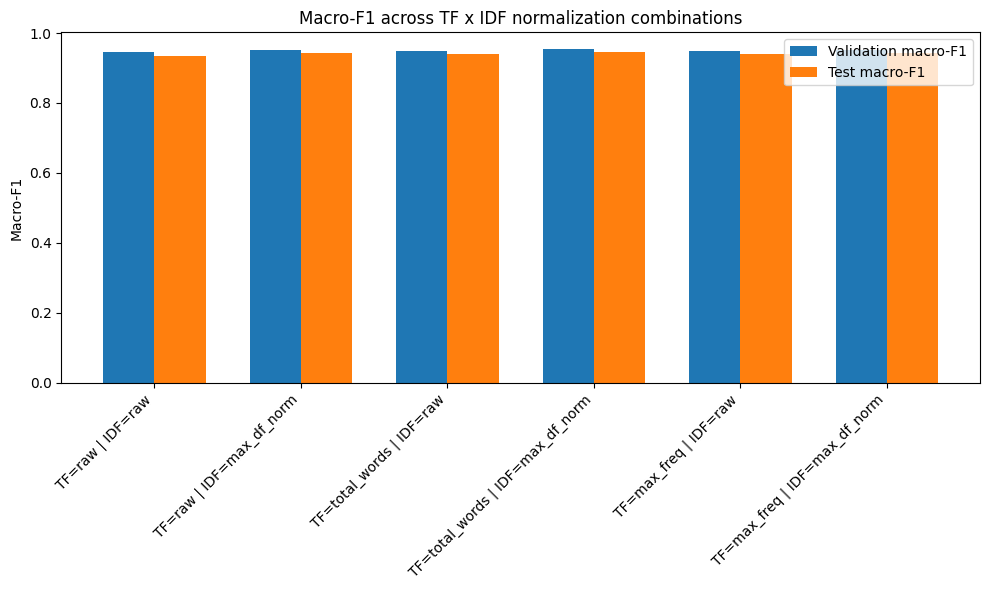

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width / 2, results_df["val_macro_f1"], width, label="Validation macro-F1")
ax.bar(x + width / 2, results_df["test_macro_f1"], width, label="Test macro-F1")

ax.set_xticks(x)
ax.set_xticklabels(results_df["combination"], rotation=45, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 across TF x IDF normalization combinations")
ax.legend()
fig.tight_layout()
plt.show()


## Step 10: Save results


In [14]:
results_df.to_csv("tf_idf_normalization_comparison.csv", index=False)

best_combo = results_df_sorted.iloc[0]
print(f"Best combination on test macro-F1: {best_combo['combination']} "
      f"(test_macro_f1={best_combo['test_macro_f1']:.4f})")

best_tf, best_idf = best_combo["tf_mode"], best_combo["idf_mode"]
best_model = trained_models[(best_tf, best_idf)]

with open("best_tfidf_model.pkl", "wb") as f:
    pickle.dump({
        "W": best_model.W,
        "b": best_model.b,
        "tf_mode": best_tf,
        "idf_mode": best_idf,
        "vocabulary": vocabulary,
        "idf_vector": idf_vectors[best_idf],
        "lang2id": lang2id,
        "id2lang": id2lang,
    }, f)

print("Saved: tf_idf_normalization_comparison.csv, best_tfidf_model.pkl")


Best combination on test macro-F1: TF=total_words | IDF=max_df_norm (test_macro_f1=0.9457)
Saved: tf_idf_normalization_comparison.csv, best_tfidf_model.pkl


## Notes / how to interpret the comparison

- **Combination `TF=raw | IDF=raw`** reproduces the previous assignment's unnormalized
  TF-IDF baseline — use it as the reference point.
- **Total-words TF normalization** tends to help most when sentence lengths vary a lot,
  since it prevents longer sentences from dominating purely because they contain more
  tokens.
- **Max-frequency TF normalization** rescales every sentence so its most frequent term
  has weight 1; this can help when a handful of high-frequency function words dominate
  raw counts, but can also over-emphasize sentences with one very repetitive term.
- **Max-df IDF normalization** makes the single most common term across the corpus
  carry zero weight (by construction) and scales all other terms relative to it, which
  behaves differently from the smoothed-log IDF especially for very frequent script- or
  language-marking character n-grams.
- Compare `val_macro_f1` and `test_macro_f1` together: a combination that overfits the
  validation set but not the test set is a sign of instability, not real improvement.
- All 6 models were trained with the **same vocabulary, hyperparameters, random seed,
  and number of epochs** — the only variable being compared is the TF/IDF weighting
  scheme.
